#Work completed by Joel Vinas

### Links ###
* Google CoLab: https://colab.research.google.com/drive/193eqxMZ5K-kmz6t5hMKiog-wKj3iqqYY?usp=sharing

* GitHub:
* YouTube:



# Section A

## Part 1: Regression

***Task**: Perform linear, polynomical and multi-linear regression for a dataset*

First, let's look at the Insurance dataset.
Is there is a relationship between Body-Mass Index (BMI) and the insurance charges incurred. With BMI often being used (incorrectly) as a metric for health, it seems reasonable that there should be some kind of a relationship.

How real is this hypothesis?

In [ ]:
#Regression:
source_file_url = "https://raw.githubusercontent.com/joelvinas/COMP-SCI_5565/refs/heads/main/Final%20Project/data/insurance.csv"
insurance_data <- read.csv(source_file_url)

head(insurance_data)

,age,sex,bmi,children,smoker,region,charges
,<int>,<chr>,<dbl>,<int>,<chr>,<chr>,<dbl>
1,19,female,27.900,0,yes,southwest,16884.924
2,18,male,33.770,1,no,southeast,1725.552
3,28,male,33.000,3,no,southeast,4449.462
4,33,male,22.705,0,no,northwest,21984.471
5,32,male,28.880,0,no,northwest,3866.855
6,31,female,25.740,0,no,southeast,3756.622


Let's make a slight modification to the dataset, to be able to discriminate between the North and South regions.

Does the data show an interesting relationship?

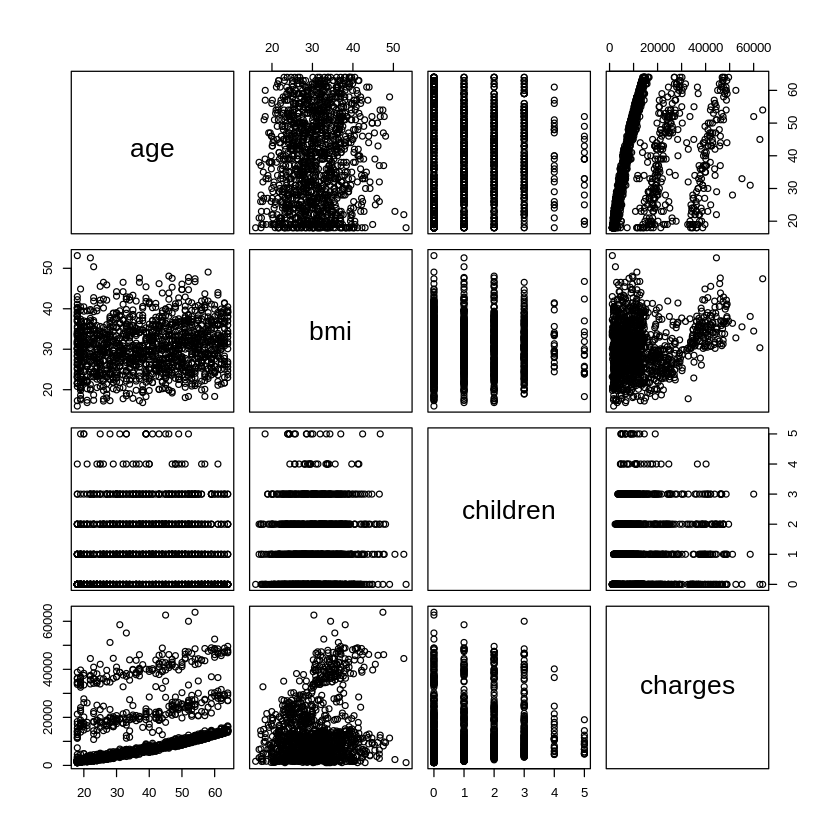

In [9]:
par(mfrow = c(1,1))

# Identify numeric columns in bank_data
numeric_insurance_data <- insurance_data[, sapply(insurance_data, is.numeric)]

pairs(numeric_insurance_data)

It's certainly not an obvious relationship, but there's something to BMI and charges. Let's chart it out.

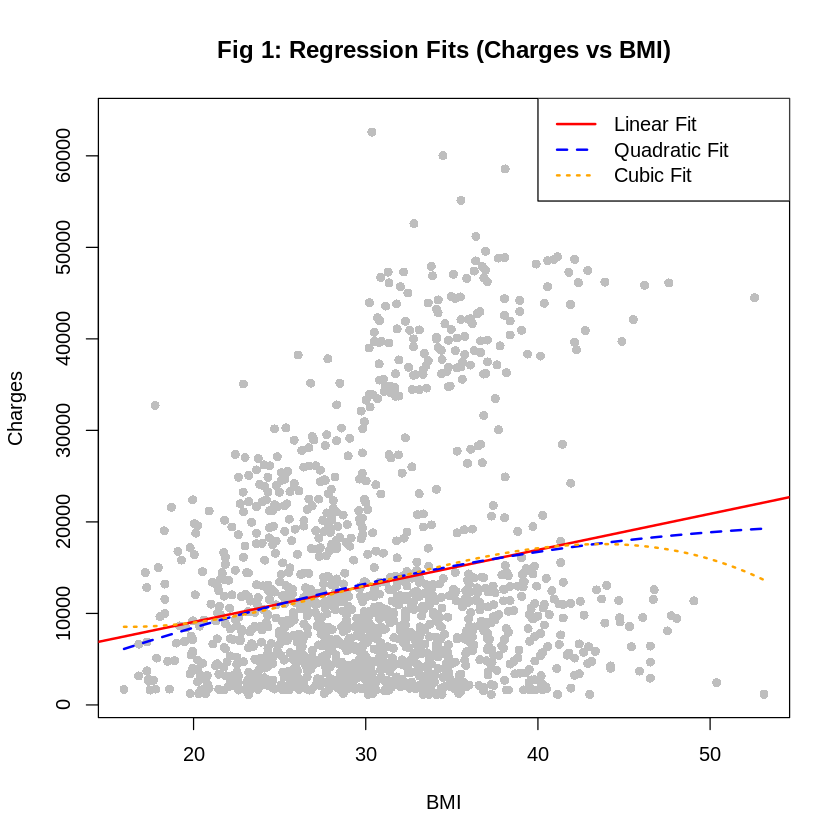

In [26]:
# Fit various models for BMI vs Charges
lm.fit <- lm(charges ~ bmi, data = insurance_data) # Corrected data source to insurance_data
lm.fit_quad <- lm(charges ~ poly(bmi, 2), data = insurance_data)
lm.fit_cubic <- lm(charges ~ poly(bmi, 3), data = insurance_data)

# Plot the Linear, Quadratic, Cubic, and Multilinear Regressions
plot(insurance_data$bmi, insurance_data$charges,
     main = "Fig 1: Regression Fits (Charges vs BMI)",
     xlab = "BMI", ylab = "Charges",
     col = "gray", pch = 16) # Scatter plot points

# Add linear fit
abline(lm.fit, lwd = 2, col = "red", lty = 1)

# Generate a sequence of BMI for smooth curve
bmi_seq <- seq(min(insurance_data$bmi), max(insurance_data$bmi), length.out = 100)

# Add quadratic fit and plot it
predicted_charges_quad <- predict(lm.fit_quad, newdata = data.frame(bmi = bmi_seq))
lines(bmi_seq, predicted_charges_quad, col = "blue", lwd = 2, lty = 2)

# Add cubic fit and plot that too
predicted_charges_cubic <- predict(lm.fit_cubic, newdata = data.frame(bmi = bmi_seq))
lines(bmi_seq, predicted_charges_cubic, col = "orange", lwd = 2, lty = 3)

legend("topright",
       legend = c("Linear Fit", "Quadratic Fit", "Cubic Fit"),
       col = c("red", "blue", "orange"), lty = c(1, 2, 3), lwd = 2)

**Analysis:**
The chart shows that, the higher the BMI, the higher the charges - although the relationship isn't terribly clear.

What if we looked at more parameters? Could a multiple linear regression prove useful here?

To perform the multiple linear relationship, let's first narrow down to a few important parameters.

In [27]:
lm.fit_multi <- lm(charges ~ ., data = insurance_data)
summary(lm.fit_multi)


Call:
lm(formula = charges ~ ., data = insurance_data)

Residuals:
     Min       1Q   Median       3Q      Max 
-11304.9  -2848.1   -982.1   1393.9  29992.8 

Coefficients: (1 not defined because of singularities)
                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)       -11938.5      987.8 -12.086  < 2e-16 ***
age                  256.9       11.9  21.587  < 2e-16 ***
sexmale             -131.3      332.9  -0.394 0.693348    
bmi                  339.2       28.6  11.860  < 2e-16 ***
children             475.5      137.8   3.451 0.000577 ***
smokeryes          23848.5      413.1  57.723  < 2e-16 ***
regionnorthwest     -353.0      476.3  -0.741 0.458769    
regionsoutheast    -1035.0      478.7  -2.162 0.030782 *  
regionsouthwest     -960.0      477.9  -2.009 0.044765 *  
isSouthRegionTRUE       NA         NA      NA       NA    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 6062 on 1329 degrees of freedom
Multiple R

The key factors here seem to be:
* age
* bmi
* smoker
* children

We currently have a 2-factor chart. Adding too many dimensions can crowd the chart, and detract from a clear comparison. For this, let's just consider the first two (bmi & age), and see how that plots out.

In [38]:
lm.fit_multi <- lm(charges ~ bmi+age, data = insurance_data)
summary(lm.fit_multi)


Call:
lm(formula = charges ~ bmi + age, data = insurance_data)

Residuals:
   Min     1Q Median     3Q    Max 
-14457  -7045  -5136   7211  48022 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) -6424.80    1744.09  -3.684 0.000239 ***
bmi           332.97      51.37   6.481 1.28e-10 ***
age           241.93      22.30  10.850  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 11390 on 1335 degrees of freedom
Multiple R-squared:  0.1172,	Adjusted R-squared:  0.1159 
F-statistic:  88.6 on 2 and 1335 DF,  p-value: < 2.2e-16


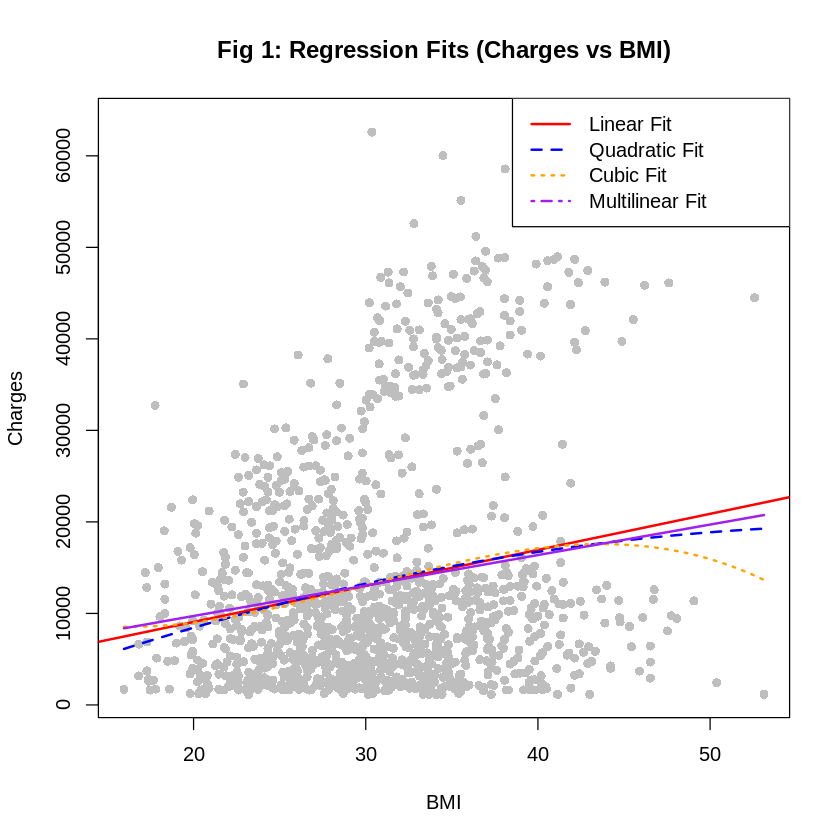

In [37]:
# Plot the Linear, Quadratic, Cubic, and Multilinear Regressions
plot(insurance_data$bmi, insurance_data$charges,
     main = "Fig 1: Regression Fits (Charges vs BMI)",
     xlab = "BMI", ylab = "Charges",
     col = "gray", pch = 16) # Scatter plot points

# Add linear fit
abline(lm.fit, lwd = 2, col = "red", lty = 1)

# Generate a sequence of BMI for smooth curve
bmi_seq <- seq(min(insurance_data$bmi), max(insurance_data$bmi), length.out = 100)

# Predict, and add quadratic fit and plot it
predicted_charges_quad <- predict(lm.fit_quad, newdata = data.frame(bmi = bmi_seq))
lines(bmi_seq, predicted_charges_quad, col = "blue", lwd = 2, lty = 2)

# Predict, and add cubic fit and plot that too
predicted_charges_cubic <- predict(lm.fit_cubic, newdata = data.frame(bmi = bmi_seq))
lines(bmi_seq, predicted_charges_cubic, col = "orange", lwd = 2, lty = 3)

# Predict, and add the multilinear fit line to the plot
predicted_charges_multi <- predict(lm.fit_multi, newdata = newdata_lm_fit_multi)
lines(bmi_seq, predicted_charges_multi, col = "purple", lwd = 2, lty = 1)

legend("topright",
       legend = c("Linear Fit", "Quadratic Fit", "Cubic Fit", "Multilinear Fit"),
       col = c("red", "blue", "orange", "purple"), lty = c(1, 2, 3, 4), lwd = 2)

**Analysis:** The linear method gets close, but the quadratic fit is much closer to capturing the unique shape of the data.

The cubic considerably improves on this fit, however it not only adds more complexity, but adds the risk of exaggerating values at the tail.

The multilinear fit edges closer to the quadratic fit, while remaining linear. It's a better fit, but comes at requiring more data.

## Part 2: Feature Selection / Model Optimization Methods

1. Perform a Forward Stepwise Selection and a Backward Stepwise Selection

Reference Chapter 6 lab, change the direction for backward selection. You may utilize K-fold methods to compare ideal selections for each case. If you are using categorical data, make sure you convert the source data using the appropriate function, and that you are using the correct evaluation
metrics.  

2. RSS and Adjusted R2

Using the models generated for the feature selection, generate the plots of RSS and Adjusted R2 for forward and backward features (as given in the exercise for chapter 6).
3. PCR  

Perform a PCR on your selected data as detailed in Chapter 6 lab. Most of the datasets should have sufficient features to make this task interesting. Generate a plot of the components relative to their fit target.

## Part 3: Classification     
Complete the following objectives utilizing the data set you selected as ideal for: Classification  

Note: you should use the exercise from Chapter 4 and 5 as a reference  
Chapter 4 (Classification)
Chapter 5 (Sampling)

Generate two Classification Models for based on your given data.  
These models will include Logistic Regression, Linear Discriminant Analysis, as given in the chapter
4 lab exercise.  
Note: You'll need to make sure you properly encode any categorical data for your classes or predictions.

In [39]:
#Regression:
# What is the relationship between <Bank> Balance and Duration of Loan?
# What is the relationship between <Insurance> BMI and Charges?

#Feature Selection:
# What are the most significant parameters within the <Insurance> dataset to determine Charges?
# What are the most significant parameters within the <Adult Income> dataset to determine if someone makes above 50k?
#Principal Component Regression Reference:
# https://github.com/intro-stat-learning/ISLP_labs/blob/main/Ch06-varselect-lab.ipynb

#Classification:
# Can we classify the <Insurance> dataset to get a high-fit model?
# LDA, Logistic Regression

#Section B

## Part 1: Splines
Complete the following objectives utilizing the data set you selected as ideal for: Natural
and Cubic Splines   
https://github.com/intro-stat-learning/ISLP_labs/blob/main/Ch07-nonlin-lab.ipynb

* Polynomial Regression and Step Functions:   
  * Try out different degrees and deliver the changes observed through
discussion/comments.  
* Splines  
  * of Basis-Spline and Natural-Spline (as given in the lab) and two new fits of df 9 and 22. (substitute the values as given in the assignment) What would you conclude from the results generated from the fits given by df 16,22 compared to the default in the lab for both the B-spline and N
spline?

## Part 2: Tress and SVM      

Complete the following objectives utilizing the data set you selected as ideal for: Trees and SVM  
Note: you may use the exercise from Chapter 8 and 9 as a reference link here -->   
Chapter 8 Lab , Chapter 8_R_Lab / Chapter_9_Lab , Chapter_9 R Lab  
* Trees  
  * Generate a Tree Classifier or Regressor for the classes and predictors of the chosen dataset.  
  * Perform Regression/Classification Tree, Random Forest, and  
Regression/Classification Boosting based on the dataset chosen.   
* Support Vector Machines  
  * Perform SVC and SVM for the multiclass classification with outputs resulting in decision boundary plots and confusion matrices.

## Part 3: Neural Nets    
Perform Neural Nets on image classification task on MNIST dataset, loaded as the part of the provided script (https://colab.research.google.com/drive/1myC8ppal4grFnlc9DT24C69eNV4Rh8p6?usp=sharing). Use the script provided to perform the required tasks below and the instructions
to achieve the task would be available as comments:   
Set the seed with the last 4-digits of your Student ID.  
* Try out the topology [neural net architecture] provided in the script [256,96,32,10] and implement the following topologies using the ‘sigmoid’ activation function:  
1. [96, 32, 10]   
2. [128,64,32,10]  
  * Remember to add / remove the layers as per the requested topologies.  
* Repeat, the three topologies above with a different activation function – ‘relu’.  
* Out of the [2x3 = 6] total experiments select the best performed topology with activation function for the further process (Look out for overfitting!).  

With the chosen model with best performing topology and activation function, perform the same task with change in learning rate different from the provided script originally.

**The learning rates to try are:**
1. Learning rate to try with [0.01, 0.001, 0.0001]  
2. Out of the 4 learning rates tried [default+3 new] select the learning rate with which the best-chosen performed better.   

Now, we have the best performing topology, activation function, and learning rate so far, now as the final trail try with different batch size different from the provided script originally.
The batch sizes to try with are:  
1. [32, 64]  

Provide the configurations tried using the task sheet provided as part of the instructions and paste the table before answering the below questions into the document you are supposed to submit.  
Provide the final best topology, learning rate, activation function, and batch size again the MNIST dataset

**Provide your views on the questions below:**
* Compare the topologies and provide the reason the chosen topology worked out to be the best along with the activation function?   
* Does topology and activation function depend on each other? If yes, then how and why?   
* What learning rate felt like the best choice and why?  
* What impacted the batch size on the performance of the model?  
* Are the learning rate and batch size correlated? What notable changes were observed during the entire process?

In [ ]:

# https://github.com/intro-stat-learning/ISLP_labs/blob/main/Ch07-nonlin-lab.ipynb